In [26]:
import pandas as pd
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor

import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

# Configurations

In [27]:
class CONFIG:
    seed = 42
    target_col = "responder_6"
    feature_cols = ["symbol_id", "time_id"] \
        + [f"feature_{idx:02d}" for idx in range(79)] \
        + [f"responder_{idx}_lag_1" for idx in range(9)]
    categorical_cols = []

# Load Data

In [28]:
train = pl.scan_parquet("train.parquet").collect().to_pandas()
valid = pl.scan_parquet("valid.parquet").collect().to_pandas()
train.shape, valid.shape

((21022056, 104), (1082224, 104))

In [29]:
X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
X_valid = valid[ CONFIG.feature_cols ]
y_valid = valid[ CONFIG.target_col ]
w_valid = valid[ "weight" ]

X_train.shape, y_train.shape, w_train.shape, X_valid.shape, y_valid.shape, w_valid.shape

((21022056, 90),
 (21022056,),
 (21022056,),
 (1082224, 90),
 (1082224,),
 (1082224,))

# Train naive XGb

In [30]:
def get_model(seed):
    # XGBoost parameters
    XGB_Params = {
        'learning_rate': 0.05,
        'max_depth': 6,
        'n_estimators': 200,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 1,
        'reg_lambda': 5,
        'random_state': seed,
        'tree_method': 'gpu_hist',
        'device' : 'cuda',
        'n_gpus' : 2
    }
    
    XGB_Model = XGBRegressor(**XGB_Params)
    return XGB_Model

In [31]:
model = get_model(CONFIG.seed)
model.fit( X_train, y_train, sample_weight=w_train)
y_pred_train = model.predict(X_train)
y_pred_valid = model.predict(X_valid)
train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
train_score, valid_score

(0.034636578581196065, 0.005550710799321679)

# Now change symbol_id to dummy categorical and refit naive XGb

In [44]:
train["symbol_id"] = train["symbol_id"].astype('category')
valid["symbol_id"] = valid["symbol_id"].astype('category')
X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
X_valid = valid[ CONFIG.feature_cols ]
y_valid = valid[ CONFIG.target_col ]
w_valid = valid[ "weight" ]

X_train.shape, y_train.shape, w_train.shape, X_valid.shape, y_valid.shape, w_valid.shape

((22104280, 90),
 (22104280,),
 (22104280,),
 (1082224, 90),
 (1082224,),
 (1082224,))

# Enable XGb to deal with categorical

In [45]:
def get_model(seed):
    # XGBoost parameters
    XGB_Params = {
        'learning_rate': 0.05,
        'max_depth': 6,
        'n_estimators': 200,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'reg_alpha': 1,
        'reg_lambda': 5,
        'random_state': seed,
        'tree_method': 'gpu_hist',
        'device' : 'cuda',
        'n_gpus' : 2,
        'enable_categorical': True,
        'use_label_encoder': False
    }
    
    XGB_Model = XGBRegressor(**XGB_Params)
    return XGB_Model

# Train on training set only

In [34]:
# train on training set only
training = False
if training:
    model = get_model(CONFIG.seed)
    model.fit( X_train, y_train, sample_weight=w_train)
    y_pred_train = model.predict(X_train)
    y_pred_valid = model.predict(X_valid)
    train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
    valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    train_score, valid_score

# train score, valid score
# (0.036868743428252526, 0.006652281256338433)

# Combine train and valid, and re-train XGB on whole dataset

In [35]:
# # Trick of boosting LB score: 0.45->0.49

print(X_train.shape, X_valid.shape)
train = pd.concat([train, valid]).reset_index(drop=True)
print(X_train.shape, X_valid.shape)

(21022056, 90) (1082224, 90)
(21022056, 90) (1082224, 90)


In [47]:
X_train = train[ CONFIG.feature_cols ]
y_train = train[ CONFIG.target_col ]
w_train = train[ "weight" ]
print(X_train.dtypes)


symbol_id            category
time_id                 int16
feature_00            float32
feature_01            float32
feature_02            float32
                       ...   
responder_4_lag_1     float32
responder_5_lag_1     float32
responder_6_lag_1     float32
responder_7_lag_1     float32
responder_8_lag_1     float32
Length: 90, dtype: object


In [42]:
training = False
if training:
    model = get_model(CONFIG.seed)
    model.fit( X_train, y_train, sample_weight=w_train)
    y_pred_train = model.predict(X_train)
    y_pred_valid = model.predict(X_valid)
    train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
    valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    print(train_score, valid_score)
else:
    xgb_model = None
    model_path = "XGB.pkl"
    with open( model_path, "rb") as fp:
        result = pickle.load(fp)
        xgb_model = result["model"]
    y_pred_train = model.predict(X_train)
    y_pred_valid = model.predict(X_valid)
    train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
    valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
    print(train_score, valid_score)

0.033637300375636836 0.013063235774804838


In [50]:
print(X_train.shape, X_valid.shape)
y_pred_valid = model.predict(X_valid)
print(X_valid.shape)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
print(X_valid.shape, valid_score)
y_pred_valid = xgb_model.predict(X_valid)
print(X_valid.shape)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
print(X_valid.shape, valid_score)


(22104280, 90) (1082224, 90)
(1082224, 90)
(1082224, 90) 0.005550710799321679
(1082224, 90)
(1082224, 90) 0.012489498104867436


In [51]:
xgb_model = None
model_path = "XGB.pkl"

print(X_valid.shape)


with open( model_path, "rb") as fp:
    result = pickle.load(fp)
    xgb_model = result["model"]

print(X_valid.shape)

y_pred_train = xgb_model.predict(X_train)
y_pred_valid = xgb_model.predict(X_valid)
print(X_valid.shape)
train_score = r2_score(y_train, y_pred_train, sample_weight=w_train )
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
print(X_valid.shape)
print(train_score, valid_score)

(1082224, 90)
(1082224, 90)
(1082224, 90)
(1082224, 90)
0.03503797343254367 0.012489498104867436


# CV by symbol_id

In [ ]:
cross_validation = False
if cross_validation:
    cv_detail = { symbol_id : 0 for symbol_id in range(39) }
    for symbol_id, gdf in valid.groupby("symbol_id"):
        X_valid = gdf[ CONFIG.feature_cols ]
        y_valid = gdf[ CONFIG.target_col ]
        w_valid = gdf[ "weight" ]
        y_pred_valid = model.predict(X_valid)
        score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
        cv_detail[symbol_id] = score
        
        print(f"symbol_id = {symbol_id}, score = {score:.5f}")

symbol_id = 0, score = -0.00480
symbol_id = 1, score = 0.00273
symbol_id = 2, score = 0.00135
symbol_id = 3, score = 0.00433
symbol_id = 4, score = 0.01730
symbol_id = 5, score = 0.00253
symbol_id = 6, score = 0.00270
symbol_id = 7, score = -0.00295
symbol_id = 8, score = 0.00933
symbol_id = 9, score = 0.01109
symbol_id = 10, score = 0.00427
symbol_id = 11, score = 0.00923
symbol_id = 12, score = 0.00172
symbol_id = 13, score = 0.04808
symbol_id = 14, score = 0.00348
symbol_id = 15, score = -0.00030
symbol_id = 16, score = 0.00747
symbol_id = 17, score = 0.01717
symbol_id = 18, score = 0.00454
symbol_id = 19, score = -0.03688
symbol_id = 20, score = 0.01815
symbol_id = 21, score = 0.00339
symbol_id = 22, score = 0.02490
symbol_id = 23, score = -0.00105
symbol_id = 24, score = 0.00051
symbol_id = 25, score = 0.01709
symbol_id = 26, score = -0.00248
symbol_id = 27, score = 0.00029
symbol_id = 28, score = 0.00561
symbol_id = 29, score = 0.00290
symbol_id = 30, score = -0.00106
symbol_id =

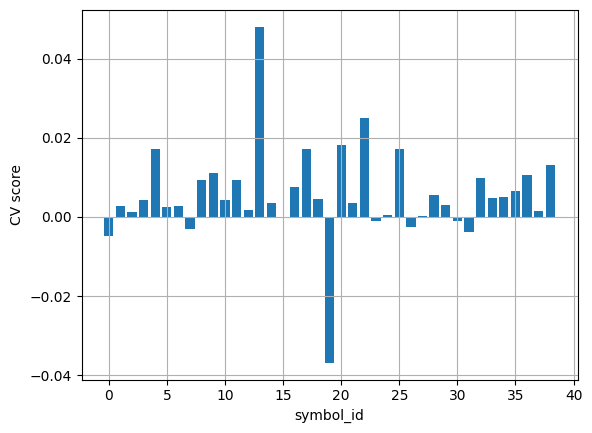

In [40]:
sids = list(cv_detail.keys())
plt.bar(sids, [cv_detail[sid] for sid in sids])
plt.grid()
plt.xlabel("symbol_id")
plt.ylabel("CV score")
plt.show()

# Save the XGB model

In [ ]:
save_model = False
if save_model:
    result = {
        "model" : model
    }
    with open("XGB.pkl", "wb") as fp:
        pickle.dump(result, fp)